In [75]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.io import loadmat
from mne.time_frequency import tfr_morlet
from tqdm import tqdm


In [58]:
data = np.load("../final project/preprocessed_data/sub-01/preprocessed_eeg_training.npz")
print(data.files)

['preprocessed_eeg_data', 'ch_names', 'times']


In [63]:
eeg = data["preprocessed_eeg_data"]
fs = 500

In [ ]:
data['ch_names']

array(['Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'P1', 'P5', 'PO7',
       'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2'], dtype='<U3')

In [ ]:
print(data.files)

['preprocessed_eeg_data', 'ch_names', 'times']


In [ ]:
eeg.shape
#time being -0.2 - 0.8

(16540, 4, 17, 500)

In [64]:
data2 = np.load("../final project/my_preprocessed_data/sub-01/preprocessed_eeg_train.npz")
print(data2.files)

['preprocessed_eeg_data', 'ch_names']


In [65]:
data2['ch_names']

array(['O1', 'Oz', 'O2', 'PO3', 'PO4', 'PO7', 'PO8', 'POz'], dtype='<U3')

In [ ]:
data['ch_names'].tolist()

['Pz',
 'P3',
 'P7',
 'O1',
 'Oz',
 'O2',
 'P4',
 'P8',
 'P1',
 'P5',
 'PO7',
 'PO3',
 'POz',
 'PO4',
 'PO8',
 'P6',
 'P2']

### Remove offset

In [ ]:
eeg = eeg - eeg.mean(axis=-1, keepdims=True)

KeyboardInterrupt: 

In [ ]:
eeg_epoch = eeg[0, 0]
eeg_epoch.shape

(17, 500)

In [ ]:
times = data["times"]
dt = np.mean(np.diff(times))
fs = 1.0 / dt
fs

500.0

In [ ]:
info = mne.create_info(
    ch_names=data["ch_names"].tolist(),
    sfreq=fs,
    ch_types="eeg",
)

eeg_epoch = eeg[0, 1]
raw = mne.io.RawArray(eeg_epoch, info)

Creating RawArray with float64 data, n_channels=17, n_times=500
    Range : 0 ... 499 =      0.000 ...     0.998 secs
Ready.


Using matplotlib as 2D backend.


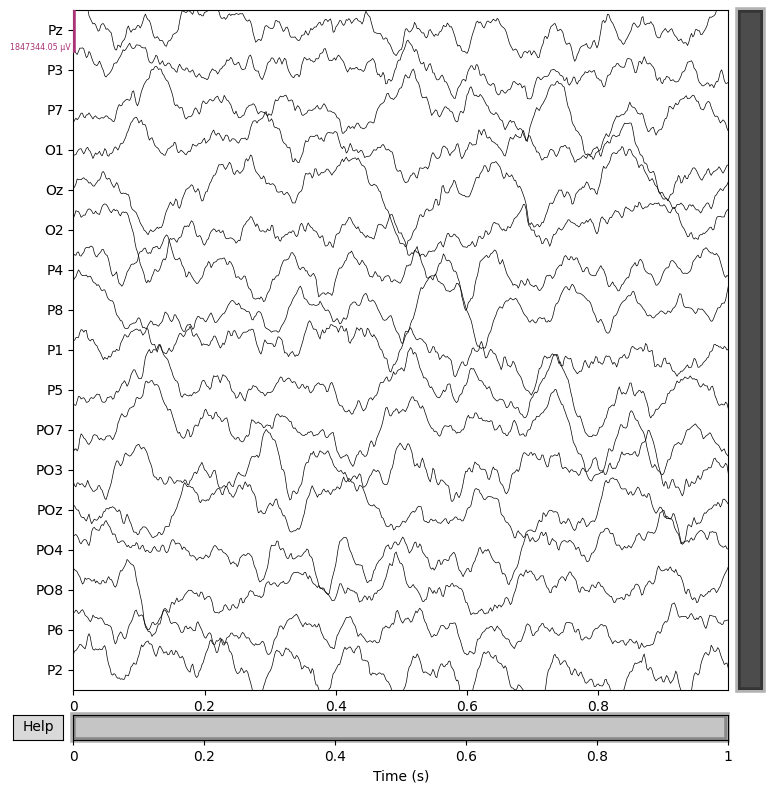

In [ ]:
# Time series browser
raw.plot(n_channels=17, scalings='auto');

# # Power spectral density
# raw.plot_psd(fmax=50)

In [ ]:
beh = loadmat("../final project/sub-01/ses-01/beh/sub-01_ses-01_task-train_part-01_beh.mat")
print(beh.keys())

# This should be used for aggreation of data, for sub-01 there's 16540 unique images shown
# and each image is shown for 4 times 
# the first aggregation for spectral power is per each image 
# the second is using the beh files and see if we can map each image to the corresponding category
# then aggreate the spectral power by category 

dict_keys(['__header__', '__version__', '__globals__', 'data'])


### Bandpass Filter

In [ ]:
#1 Hz to not get dominated by slow drifts
#40 Hz to focus and away from Nyquist edge
raw.filter(1, 10, fir_design='firwin')

# Save cleaned data
cleaned_data = raw.get_data()
# np.savez("cleaned_eeg_training.npz", eeg=cleaned_data)

print("MNE preprocessing complete.")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 1651 samples (3.302 s)

MNE preprocessing complete.


/var/folders/fb/vl659_wn3_51grkn2086ffs00000gn/T/ipykernel_71055/1875440601.py:3: RuntimeWarning: filter_length (1651) is longer than the signal (500), distortion is likely. Reduce filter length or filter a longer signal.
  raw.filter(1, 10, fir_design='firwin')
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


In [ ]:
clean_obj = mne.io.RawArray(cleaned_data, info)

Creating RawArray with float64 data, n_channels=17, n_times=500
    Range : 0 ... 499 =      0.000 ...     0.998 secs
Ready.


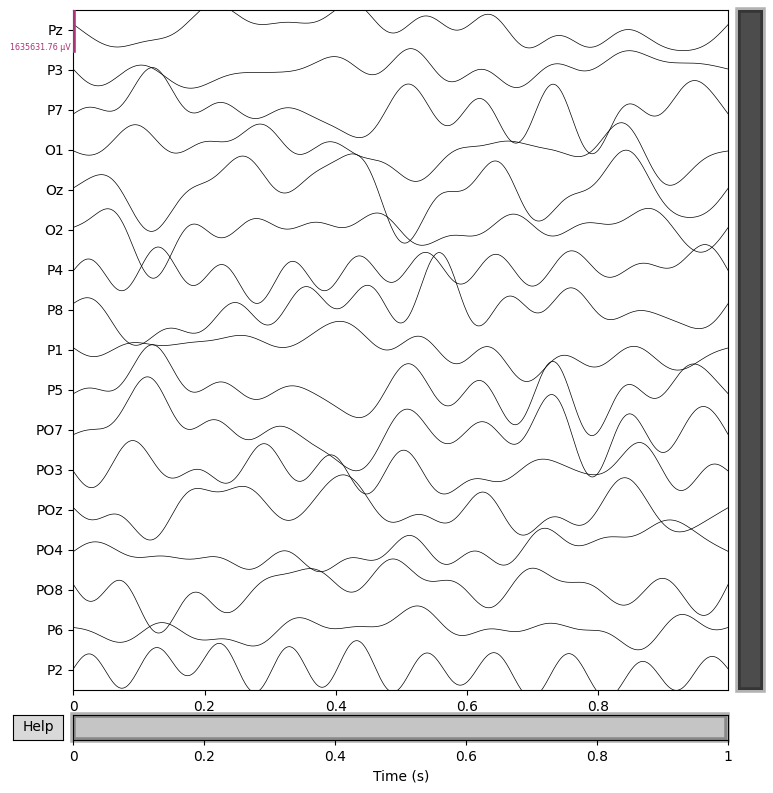

In [ ]:
clean_obj.plot(n_channels=17, scalings='auto');

# TODO:

create spectrogram using this single sample and plot graphs

In [ ]:
# 1. Check your total duration to be sure
total_duration = raw.times[-1]
print(f"Your data is {total_duration:.2f} seconds long.")

# 2. Create epochs that fit your data length
# We'll use a 1-second window to be safe, or half the total duration
target_duration = min(1.0, total_duration) 

epochs = mne.make_fixed_length_epochs(
    raw, 
    duration=target_duration, 
    preload=True, 
    reject_by_annotation=False  # This ignores "BAD" segments
)

freqs = np.arange(1, 41, 1)
n_cycles = freqs / 2.

tfr = tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, return_itc=False)

times = data["times"]  # original -0.2 … 0.8, length M
n_tfr = tfr.times.shape[0]

# Stretch/compress the original range to match TFR length
tfr.times = np.linspace(times[0], times[-1], num=n_tfr)

tfr.plot([0], title="Corrected EEG Spectrogram")
# 4. Plot the first channel
tfr.plot([0], title="Corrected EEG Spectrogram")

Your data is 1.00 seconds long.
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 499 original time points ...
0 bad epochs dropped


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


AttributeError: can't set attribute

In [ ]:
times.shape[0], tfr.times.shape[0]

(500, 499)

In [ ]:
times[:-1].shape

(499,)

In [60]:
eeg_epochs = eeg[0, 0, :, :]

# tmin = first entry in your times vector (e.g. -0.2)
epochs = mne.EpochsArray(eeg_epochs, info, tmin=float(times[0]))

# Time–frequency
freqs = np.arange(1, 41, 1)
n_cycles = freqs / 2.0

tfr = tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, return_itc=False)

# Plot first channel; x-axis will now reflect your epoch timing
tfr.plot([0], title="Corrected EEG Spectrogram")

ValueError: Data must be a 3D array of shape (n_epochs, n_channels, n_samples)

New Data Shape: (1, 17, 500)
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


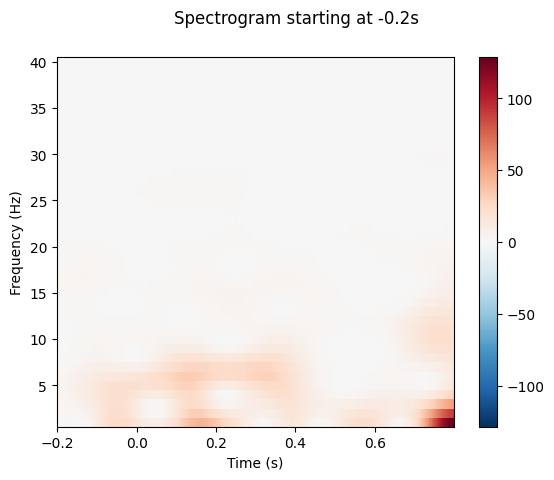

[<Figure size 640x480 with 2 Axes>]

In [74]:
import numpy as np
import mne
from mne.time_frequency import tfr_morlet

# Assume your 'eeg' variable is what you're slicing from
# If eeg is already (Channels, Times), we make it (1, Channels, Times)
single_epoch_data = eeg[0, 0, :, :] # This looks like it's coming from a 4D source

# --- CRITICAL FIX ---
# Force it into 3D: (n_epochs, n_channels, n_times)
if single_epoch_data.ndim == 2:
    single_epoch_data = single_epoch_data[np.newaxis, :, :]
elif single_epoch_data.ndim == 1:
    # If it's just a single channel's worth of data
    single_epoch_data = single_epoch_data[np.newaxis, np.newaxis, :]

print(f"New Data Shape: {single_epoch_data.shape}") # Should be (1, 1, samples) or (1, channels, samples)
# --------------------

# Now create the EpochsArray
start_time = float(times[0])
epochs = mne.EpochsArray(single_epoch_data, info, tmin=start_time)

# Run Time-frequency
freqs = np.arange(1, 41, 1)
n_cycles = freqs / 2.0
tfr = tfr_morlet(epochs, freqs=freqs, n_cycles=n_cycles, return_itc=False)

# Plot
tfr.plot([1], title=f"Spectrogram starting at {start_time}s")

In [67]:
data2['ch_names']

array(['O1', 'Oz', 'O2', 'PO3', 'PO4', 'PO7', 'PO8', 'POz'], dtype='<U3')

In [70]:
data['ch_names'].tolist().index('O1')

3

  0%|          | 0/8 [00:00<?, ?it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


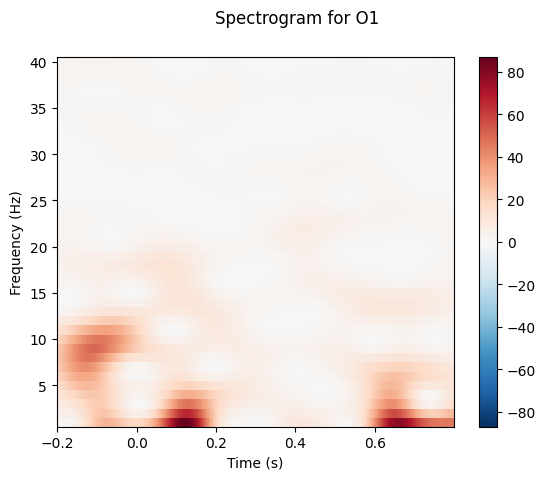

 12%|█▎        | 1/8 [00:00<00:01,  5.08it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


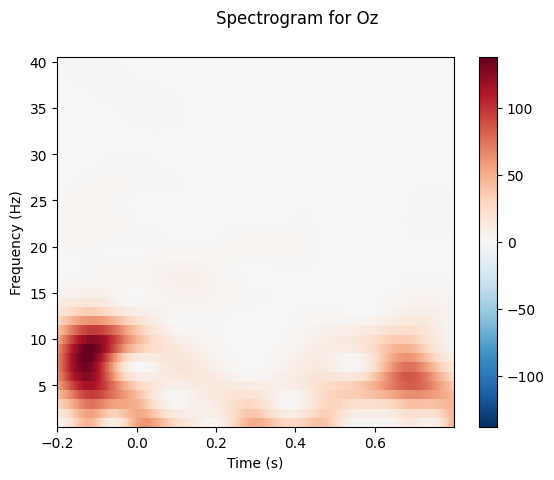

 25%|██▌       | 2/8 [00:00<00:01,  5.81it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


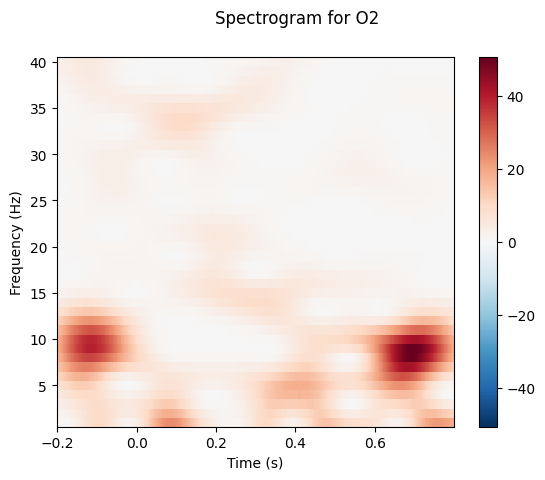

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


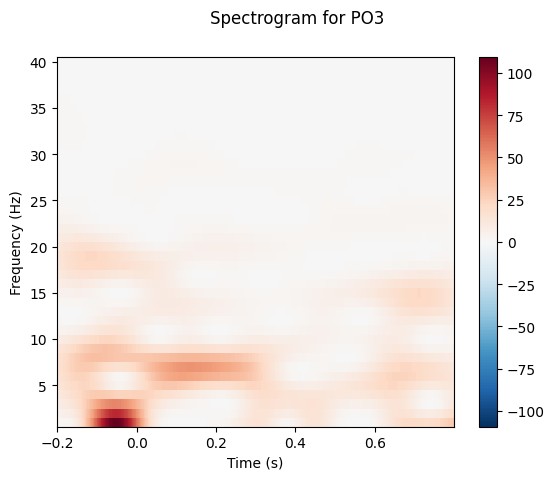

 50%|█████     | 4/8 [00:00<00:00,  7.86it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


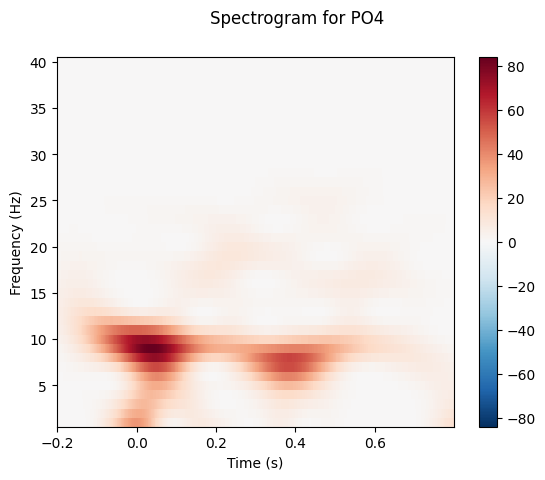

 62%|██████▎   | 5/8 [00:00<00:00,  8.37it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


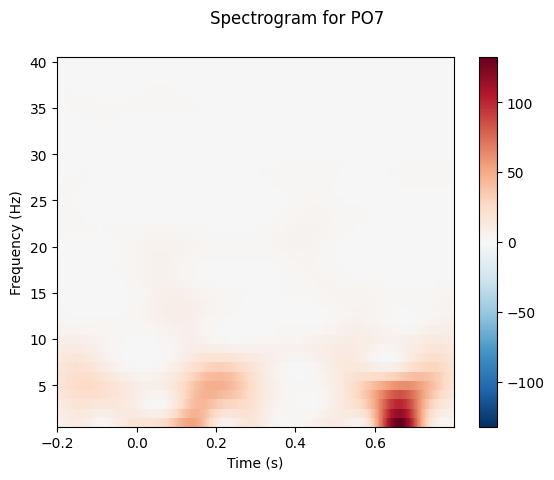

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


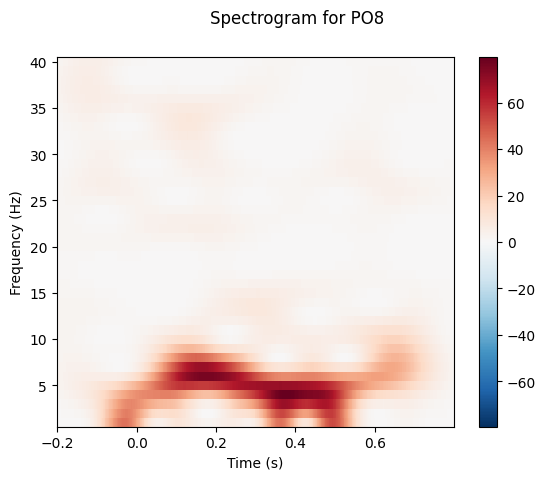

 88%|████████▊ | 7/8 [00:00<00:00,  9.19it/s]

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No baseline correction applied


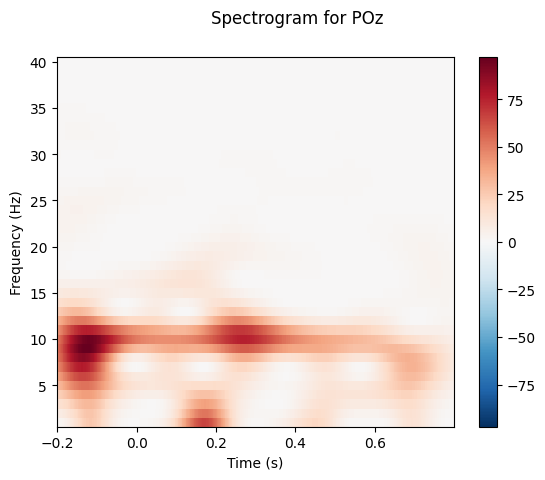

100%|██████████| 8/8 [00:00<00:00,  8.44it/s]


In [76]:
for name in tqdm(data2['ch_names']):
    cur_idx = data['ch_names'].tolist().index(name)
    tfr.plot([cur_idx], title=f"Spectrogram for {name}")
    